In [1]:
import os
import sys
import json
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.stats import sem
import os
os.environ["JAX_PLATFORMS"] = "cpu"
sys.path.append(os.path.abspath(".."))

def load_new_run_data(alg, suffix, seed, env_name, results_base_path="../results"):
    """
    Loads data from the specific folder: ../results/{alg}/{suffix}_s{seed}/{env_name}
    Note the '..' to go up from the /notebooks folder.
    """
    # 1. Construct the folder name for the seed
    run_folder = f"{suffix}_s{seed}"
    
    # 2. Join the paths
    # Result: ../results/cov_lstd/4_26_first_half_s0/Adventure-v5
    run_path = os.path.join(results_base_path, alg, run_folder, env_name)
    
    # Absolute paths are safer when working in notebooks
    run_path = os.path.abspath(run_path)
    
    config_path = os.path.join(run_path, "config.json")
    metrics_path = os.path.join(run_path, f"seed_{seed}_metrics.npz")
    
    if not os.path.exists(config_path):
        # This will now print the EXACT path it's looking for so you can verify
        raise FileNotFoundError(f"Config not found at {config_path}")
    
    with open(config_path, 'r') as f:
        config = json.load(f)
        
    if not os.path.exists(metrics_path):
        raise FileNotFoundError(f"Metrics not found at {metrics_path}")
        
    with np.load(metrics_path, allow_pickle=True) as data:
        metrics = {k: jnp.array(v) for k, v in data.items()}
        
    return config, metrics

def aggregate_new_runs(env, alg, suffix, n_seeds=4, metric_key='returned_episode_returns'):
    """
    Aggregates across seeds for the new directory structure.
    """
    all_seed_metrics = []
    final_config = None

    for s in range(n_seeds):
        try:
            config, metrics = load_new_run_data(alg, suffix, s, env)
            all_seed_metrics.append(metrics)
            final_config = config
        except Exception as e:
            print(f"Skipping seed {s} for {alg}/{suffix}: {e}")

    if not all_seed_metrics:
        raise ValueError(f"No data found for {alg}/{suffix} in {env}")

    # Stack all keys found in the metrics
    stacked_metrics = jax.tree_util.tree_map(lambda *xs: jnp.stack(xs), *all_seed_metrics)
    
    # Extract the specific Y-axis data
    if metric_key in stacked_metrics:
        data_series = stacked_metrics[metric_key]
    else:
        print(f"Warning: {metric_key} not found, available: {list(stacked_metrics.keys())}")
        data_series = jnp.zeros((len(all_seed_metrics), 1))

    return final_config, data_series, stacked_metrics

In [2]:
def clip_outlier(data, factor=1.5):
    """
    Clips data to the whiskers of a box plot.
    factor=1.5 is standard; higher values (e.g., 3.0) are more conservative.
    """
    q1 = jnp.percentile(data, 5)
    q3 = jnp.percentile(data, 95)
    iqr = q3 - q1
    
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    
    return jnp.clip(data, lower_bound, upper_bound)

def plot_current_results(envs, experiments, n_seeds=3, metric_key='returned_episode_returns'):
    num_envs = len(envs)
    cols = min(num_envs, 3)
    rows = int(np.ceil(num_envs / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4), constrained_layout=True)
    if num_envs == 1: axes = [axes]
    axes = np.array(axes).flatten()

    for i, env in enumerate(envs):
        ax = axes[i]
        for exp in experiments:
            # Parse 'alg/suffix' from your label dictionary
            # Assumes format: {'label': 'ppo/my_run_v1'}
            label_parts = exp['label'].split('/')
            alg = label_parts[0]
            suffix = "/".join(label_parts[1:]) # Handles sub-folders in suffix
            
            try:
                config, data_series, _ = aggregate_new_runs(env, alg, suffix, n_seeds, metric_key)

                data_series = clip_outlier(data_series) 
                mean_val = jnp.mean(data_series, axis=0)
                std_err = sem(data_series, axis=0)
                
                # Calculate steps
                steps_per_update = config['NUM_ENVS'] * config['NUM_STEPS']
                # If your config has frame_skip (Atari usually 4)
                total_steps = jnp.arange(data_series.shape[1]) * steps_per_update * config.get('frame_skip', 4)
                
                # Statistics
                mean_val = jnp.mean(data_series, axis=0)
                std_err = sem(data_series, axis=0)
                
                line, = ax.plot(total_steps, mean_val, label=exp['label'])
                ax.fill_between(total_steps, mean_val - std_err, mean_val + std_err, alpha=0.2)
                
            except Exception as e:
                print(f"Error plotting {exp['label']} on {env}: {e}")

        ax.set_title(env, fontweight='bold')
        ax.set_xlabel("Total Environment Steps")
        ax.set_ylabel(metric_key.replace('_', ' ').title())
        ax.grid(True, alpha=0.3)
        if i == 0: ax.legend()

    # Hide unused axes
    for j in range(i + 1, len(axes)): axes[j].set_visible(False)
    
    plt.show()

def plot_mean_and_std(envs, experiments, mean_key, std_key, twin_key=None, n_seeds=3):
    num_envs = len(envs)
    num_exps = len(experiments)
    
    # Grid: Rows for Environments, Columns for Experiments
    fig, axes = plt.subplots(num_envs, num_exps, figsize=(num_exps*5, num_envs*4), constrained_layout=True)
    
    # Handle 1D cases for consistent indexing
    if num_envs == 1 and num_exps == 1: axes = np.array([[axes]])
    elif num_envs == 1: axes = axes[np.newaxis, :]
    elif num_exps == 1: axes = axes[:, np.newaxis]

    for i, env in enumerate(envs):
        for j, exp in enumerate(experiments):
            ax = axes[i, j]
            label_parts = exp['label'].split('/')
            alg, suffix = label_parts[0], "/".join(label_parts[1:])
            
            try:
                # Primary Metric
                conf, data_m, _ = aggregate_new_runs(env, alg, suffix, n_seeds, mean_key)
                _, data_s, _    = aggregate_new_runs(env, alg, suffix, n_seeds, std_key)
                data_m = clip_outlier(data_m)
                data_s = clip_outlier(data_s)
                steps = jnp.arange(data_m.shape[1]) * conf['NUM_ENVS'] * conf['NUM_STEPS'] * conf.get('frame_skip', 4)
                
                # Plot Primary (Solid)
                m_avg = jnp.mean(data_m, axis=0)
                s_avg = jnp.mean(data_s, axis=0)
                ax.plot(steps, m_avg, label=mean_key, color='tab:blue')
                ax.fill_between(steps, m_avg - s_avg, m_avg + s_avg, color='tab:blue', alpha=0.15)
                ax.set_ylabel(mean_key, color='tab:blue')

                # Twin Metric (Dashed)
                if twin_key:
                    ax2 = ax.twinx()
                    _, data_t, _ = aggregate_new_runs(env, alg, suffix, n_seeds, twin_key)
                    t_avg = jnp.mean(data_t, axis=0)
                    ax2.plot(steps, t_avg, label=twin_key, color='tab:red', linestyle='--')
                    ax2.set_ylabel(twin_key, color='tab:red')
                
                if i == 0: ax.set_title(exp['label'], fontweight='bold')
                if j == 0: ax.annotate(env, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0),
                                     xycoords=ax.yaxis.label, textcoords='offset points',
                                     size='large', ha='right', va='center', rotation=90)
                
            except Exception as e:
                ax.text(0.5, 0.5, f"Error: {e}", transform=ax.transAxes, ha='center')

    plt.show()

I0000 00:00:1777566299.629627 1189795 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


/home/users/ds541/.pyenv/versions/3.10.15/envs/atari-env/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/ds541/.pyenv/versions/3.10.15/envs/atari-env/lib/python3.10/site-packages/numpy/core/_methods.py:195: RuntimeWarning: divide by zero encountered in divide
  ret = um.true_divide(
/home/users/ds541/.pyenv/versions/3.10.15/envs/atari-env/lib/python3.10/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/users/ds541/.pyenv/versions/3.10.15/envs/atari-env/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/ds541/.pyenv/versions/3.10.15/envs/atari-env/lib/python3.10/site-packages/numpy/core/_methods.py:195: RuntimeWarning: divide by zero encountered in divide
  re

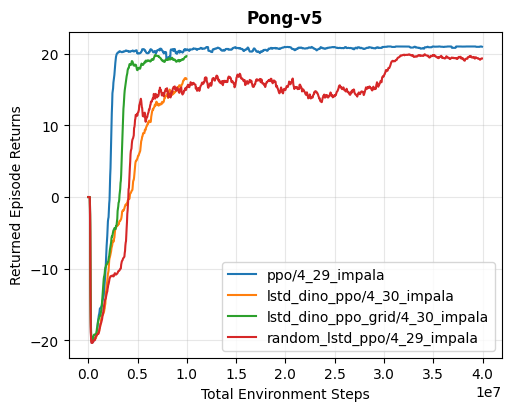

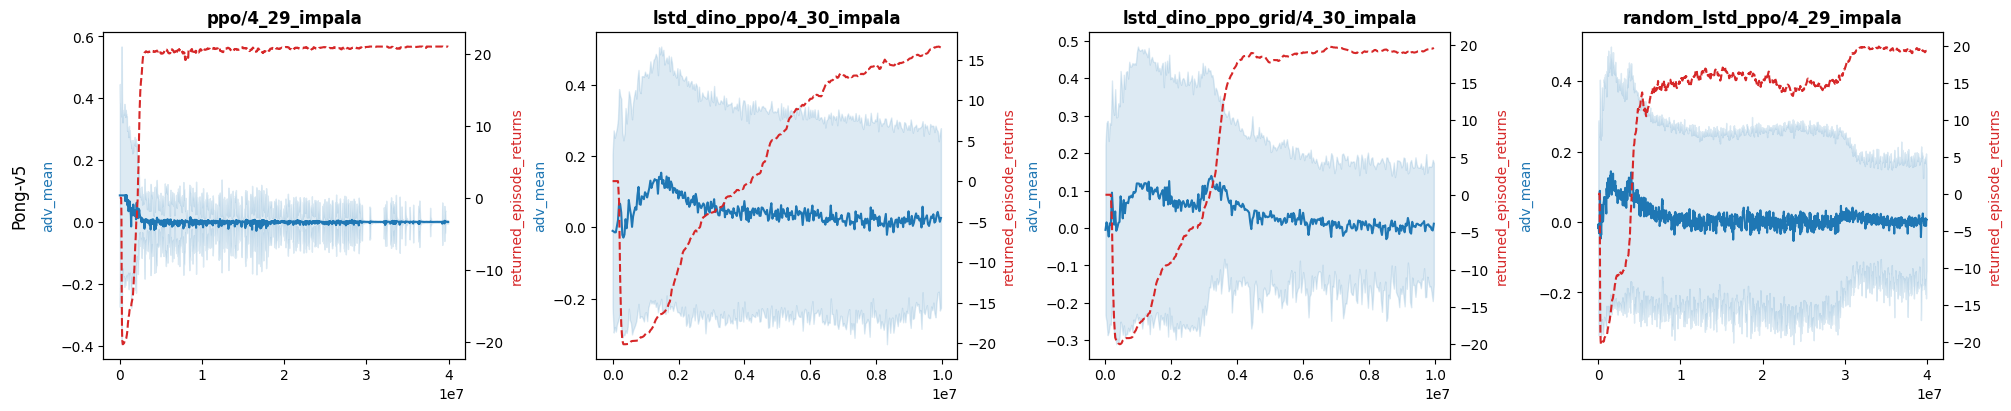

In [3]:
envs_to_plot = ["Pong-v5",]
exps = [
    {'label': 'ppo/4_29_impala'},
    {'label': 'lstd_dino_ppo/4_30_impala'},
    {'label': 'lstd_dino_ppo_grid/4_30_impala'},
    {'label': 'random_lstd_ppo/4_29_impala'}
    
]
plot_current_results(envs_to_plot, exps, n_seeds=1) 
plot_mean_and_std(envs_to_plot, exps, n_seeds=1, mean_key='adv_mean', std_key = 'adv_std',twin_key='returned_episode_returns')


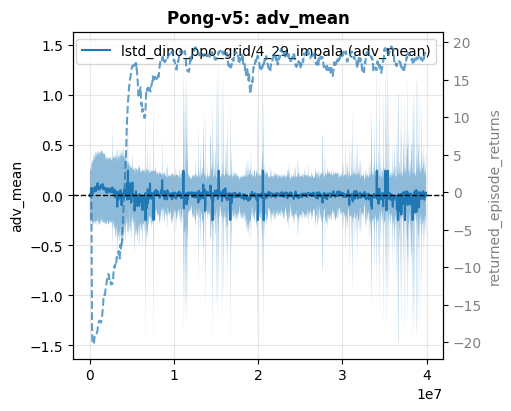

In [34]:
plot_mean_and_std(envs_to_plot, exps[1:2], n_seeds=1, mean_key='adv_mean', std_key = 'adv_std',twin_key='returned_episode_returns')

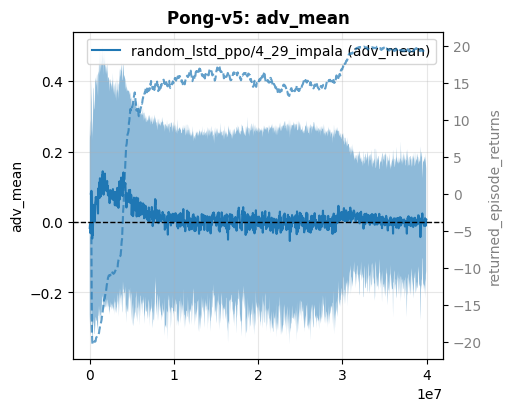

In [35]:
plot_mean_and_std(envs_to_plot, exps[2:3], n_seeds=1, mean_key='adv_mean', std_key = 'adv_std',twin_key='returned_episode_returns')

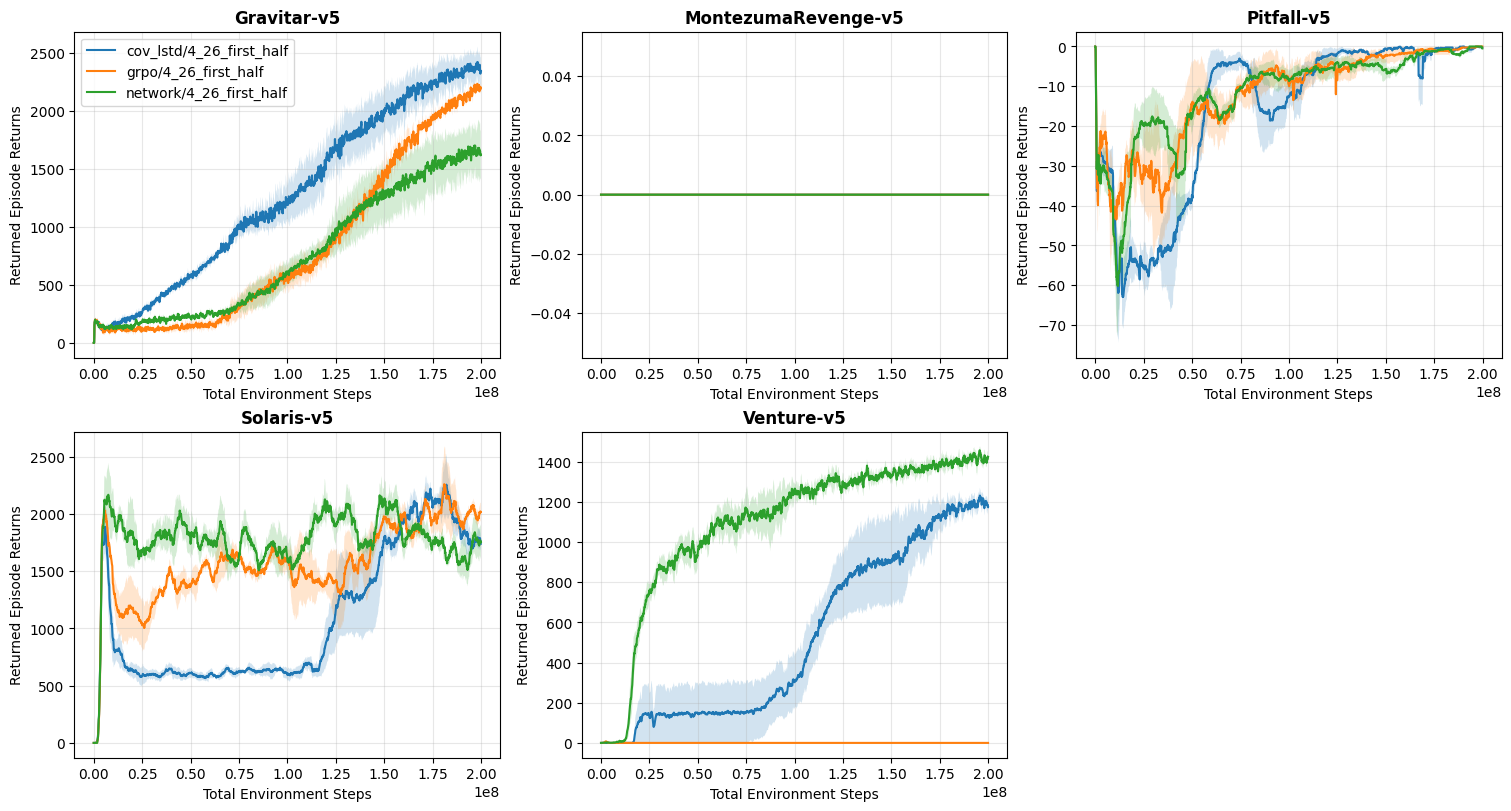

In [ ]:
envs_to_plot = ["Gravitar-v5", "MontezumaRevenge-v5", "Pitfall-v5", "Solaris-v5", "Venture-v5"]
exps = [
    {'label': 'cov_lstd/4_26_first_half'},
    {'label': 'grpo/4_26_first_half'},
    {'label': 'network/4_26_first_half'}
]
plot_current_results(envs_to_plot, exps, n_seeds=3) 

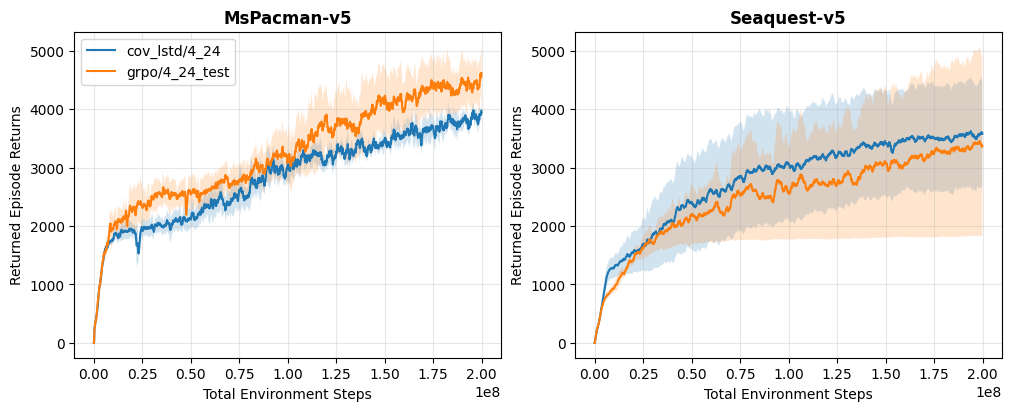

In [19]:
envs_to_plot = ["MsPacman-v5","Seaquest-v5"]
exps = [
    {'label': 'cov_lstd/4_24'},
    {'label': 'grpo/4_24_test'}
]
plot_current_results(envs_to_plot, exps, n_seeds=3) 